In [1]:
%load_ext autoreload
%autoreload 2
import requests
from dataclasses import dataclass
from ratingcalc import binsearch, calcperf

In [2]:
ratinglist = {}
ratinglist_json = requests.get("https://codeforces.com/api/user.ratedList").json()
for user in ratinglist_json["result"]:
    ratinglist[user["handle"]] = user["rating"]

print(f'Total rated users: {len(ratinglist)}')
print(list(ratinglist.items())[:10])

Total rated users: 129149
[('Benq', 3792), ('EvenImage', 3682), ('zhoukangyang', 3670), ('jiangly', 3634), ('Kevin114514', 3577), ('Geothermal', 3569), ('maroonrk', 3524), ('strapple', 3515), ('tourist', 3488), ('dXqwq', 3436)]


In [13]:
@dataclass(slots=True)
class ProblemResult:
    success: bool
    wa: int
    seconds: int


@dataclass(slots=True)
class ContestInfo:
    duration: int
    d2_scores: list
    d1_scores: list
    d2_contestant_ratings: list
    d1_contestant_ratings: list
    d2_points_to_rank: list
    d1_points_to_rank: list
    contestant_results: list[list[ProblemResult]]  # TODO: type for this


def scrape_div2(d2id: int) -> ContestInfo:
    d1id = d2id - 1
    d2_json = requests.get(f'https://codeforces.com/api/contest.standings?contestId={d2id}').json()
    d1_json = requests.get(f'https://codeforces.com/api/contest.standings?contestId={d1id}').json()
    dur = d2_json['result']['contest']['durationSeconds']
    d2_scores = [entry['points'] for entry in d2_json['result']['problems']]
    d1_scores = [entry['points'] for entry in d1_json['result']['problems']]
    d2_contestant_ratings = []
    d2_points_to_rank = []
    contestant_results = []

    for entry in d2_json['result']['rows']:
        if len(entry['party']['members']) > 1:
            continue
        handle = entry['party']['members'][0]['handle']
        rating = ratinglist.get(handle, 1400)  # the default internal rating for calculation is 1400
        r = []
        for problem in entry['problemResults']:
            r.append(ProblemResult(
                success=problem['points'] > 0,
                wa=problem['rejectedAttemptCount'],
                seconds=problem.get('bestSubmissionTimeSeconds', 999999)
            ))
        assert len(r) >= 4, 'sanity check for number of problems in this contest >= 4 failed'
        if max(r[0].seconds, r[1].seconds) > min(x.seconds for x in r[2:]):
            print(f'warn: contestant {handle} has invalid problem times (solved A/B before C/...), skipping them')
            continue
        d2_contestant_ratings.append(rating)
        d2_points_to_rank.append(entry['points'])
        contestant_results.append(r)

    d1_contestant_ratings = []
    d1_points_to_rank = []
    for entry in d1_json['result']['rows']:
        if len(entry['party']['members']) > 1:
            continue
        handle = entry['party']['members'][0]['handle']
        rating = ratinglist.get(handle, 1400)
        d1_contestant_ratings.append(rating)
        d1_points_to_rank.append(entry['points'])

    return ContestInfo(
        duration=dur,
        d2_scores=d2_scores,
        d1_scores=d1_scores,
        d2_contestant_ratings=d2_contestant_ratings,
        d1_contestant_ratings=d1_contestant_ratings,
        d2_points_to_rank=d2_points_to_rank,
        d1_points_to_rank=d1_points_to_rank,
        contestant_results=contestant_results
    )


def div2todiv1(c: ContestInfo, res: list[ProblemResult]) -> int:
    """Convert div 2 points to estimated div 1 points"""
    offset = max(res[0].seconds, res[1].seconds)
    d1_points = 0
    for i in range(2, len(res)):
        if res[i].success:
            new_seconds = res[i].seconds - offset
            new_minutes = new_seconds // 60
            original_points = c.d1_scores[i-2]
            contest_minutes = c.duration // 60
            points = original_points - int( 120 * original_points * new_minutes / (250 * contest_minutes) ) - 50 * res[i].wa
            points = max(points, original_points*0.3)
            d1_points += points
    return d1_points


def analyze(c: ContestInfo) -> list[tuple[float, float]]:
    """Analyze the contest and return a list of (div 2 perf, estimated div 1 perf)."""
    d2_rating = calcperf(c.d2_contestant_ratings)
    d1_rating = calcperf(c.d1_contestant_ratings)
    ret = []

    for i, res in enumerate(c.contestant_results):
        d2_points = c.d2_points_to_rank[i]
        d2_perf = binsearch(d2_rating, i)
        d1_points = div2todiv1(c, res)
        # D1 place is index i s.t. us >= d1_scores[i]. So this kind of rounds up a tiny bit.
        l = 0
        r = len(c.d1_points_to_rank)
        c.d1_points_to_rank.append(0)  # sentinel value
        while l < r:
            mid = l + (r-l)//2
            if d1_points < c.d1_points_to_rank[mid]:
                l = mid + 1
            else:
                r = mid
        d1_place = l
        d1_perf = binsearch(d1_rating, d1_place)
        ret.append((d2_perf, d1_perf))
    return ret



In [14]:
c = scrape_div2(2240)
data = analyze(c)
print(data[:20])

warn: contestant _AirQwQ_ has invalid problem times (solved A/B before C/...), skipping them
warn: contestant gopal.thecoder has invalid problem times (solved A/B before C/...), skipping them
warn: contestant iamburger has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Gamblr has invalid problem times (solved A/B before C/...), skipping them
warn: contestant wyh_ghm has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Bubbleawa has invalid problem times (solved A/B before C/...), skipping them
warn: contestant 137QWQ has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Sumith_chandra has invalid problem times (solved A/B before C/...), skipping them
warn: contestant anishkumar04 has invalid problem times (solved A/B before C/...), skipping them
warn: contestant rajvijay1504 has invalid problem times (solved A/B before C/...), skipping them
warn: contestant AZ_SENCS has invalid problem times (

y = 331.355 + 0.779x


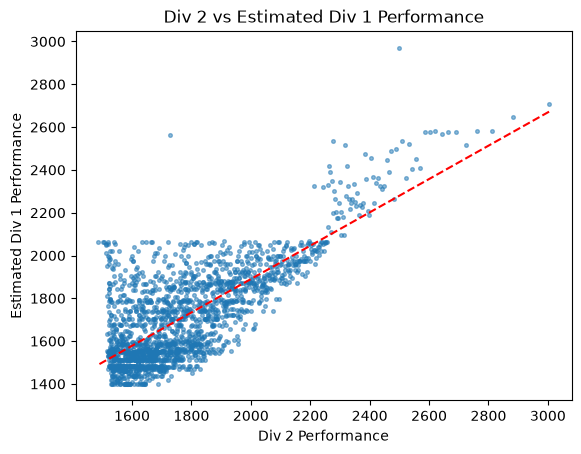

In [26]:
import numpy as np
from matplotlib import pyplot as plt

data_sanitized = [d for d in data if 1400 <= d[0] <= 3500 and 1400 <= d[1] <= 3500]

plt.scatter([x[0] for x in data_sanitized], [x[1] for x in data_sanitized], s=7, alpha=0.5)
plt.xlabel('Div 2 Performance')
plt.ylabel('Estimated Div 1 Performance')
plt.title('Div 2 vs Estimated Div 1 Performance')
z = np.polyfit([x[0] for x in data_sanitized], [x[1] for x in data_sanitized], 1)
p = np.poly1d(z)
print(f'y = {z[1]:.3f} + {z[0]:.3f}x')
plt.plot([x[0] for x in data_sanitized], p([x[0] for x in data_sanitized]), 'r--')
plt.show()

In [27]:
contests = [
    2240,  # round 1105
    2224,  # round 1097 zhili cup
    2220,  # round 1093
    2202,  # round 1082
    2197,  # round 1079
    2188,  # round 1077
    2191,  # round 1073
    2175,  # round 1069
    2166,  # round 1064
    2160,  # round 1058
    2151,  # round 1053
    2139,  # round 1048
    2136,  # round 1046
    2130,  # round 1040
    2116,  # round 1028
    2102,  # round 1024
    # 16 contests over the past just over a year
]

data = []
for contest in contests:
    c = scrape_div2(contest)
    v = analyze(c)
    data.extend(v)
    print(f'Contest {contest}: added {len(v)} records')

print(f'Total records: {len(data)}')

warn: contestant _AirQwQ_ has invalid problem times (solved A/B before C/...), skipping them
warn: contestant gopal.thecoder has invalid problem times (solved A/B before C/...), skipping them
warn: contestant iamburger has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Gamblr has invalid problem times (solved A/B before C/...), skipping them
warn: contestant wyh_ghm has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Bubbleawa has invalid problem times (solved A/B before C/...), skipping them
warn: contestant 137QWQ has invalid problem times (solved A/B before C/...), skipping them
warn: contestant Sumith_chandra has invalid problem times (solved A/B before C/...), skipping them
warn: contestant anishkumar04 has invalid problem times (solved A/B before C/...), skipping them
warn: contestant rajvijay1504 has invalid problem times (solved A/B before C/...), skipping them
warn: contestant AZ_SENCS has invalid problem times (

In [28]:
with open('data.txt', 'w') as f:
    f.write(repr(data))